## Import libraries

In [ ]:
%load_ext autoreload
%autoreload 2

from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from raccoon import WiggleCleaner
from raccoon.util import Util

## Load data

The example data used in this demo is a clipped version of the data from [Perna et al. (2023)](https://www.aanda.org/articles/aa/full_html/2023/11/aa46649-23/aa46649-23.html).

In [2]:
datacube_file = "./example_data.fits"
data_cube, header = fits.getdata(datacube_file, header=True)
# Attention: default pipeline-reduced datacubes will have the noise layer at ext=2
noise_cube = fits.getdata(datacube_file, ext=1)

wavelengths = (header["CRVAL3"] + header["CDELT3"] * np.arange(header["NAXIS3"])) * 1e4

data_cube.shape, noise_cube.shape, wavelengths.shape

((1363, 33, 33), (1363, 33, 33), (1363,))

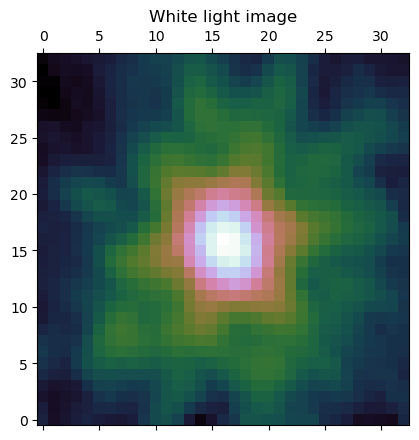

In [3]:
plt.matshow(np.log10(np.nansum(data_cube, axis=0)), cmap="cubehelix", origin="lower")
plt.title("White light image")
plt.show()

In [4]:
quasar_x, quasar_y = 16, 16

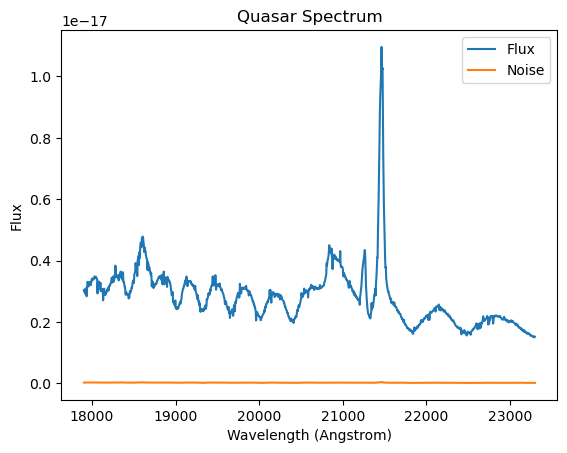

In [5]:
plt.plot(wavelengths, data_cube[:, quasar_y, quasar_x], label="Flux")
plt.plot(wavelengths, noise_cube[:, quasar_y, quasar_x], label="Noise")
plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")
plt.title("Quasar Spectrum")
plt.legend()
plt.show()

### Identify lines to make gaps in the fitting

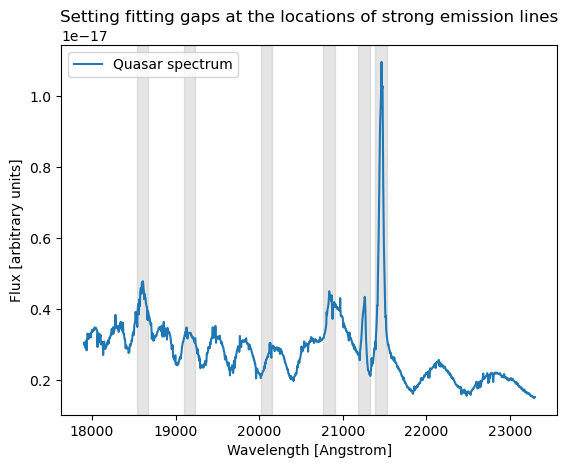

In [6]:
gaps = [
    [18541.43, 18665.54],
    [19099.23, 19227.08],
    [20016.21, 20150.19],
    [20766.39, 20905.39],
    [21183.25, 21325.04],
    [21388.00, 21531.16],
]

plt.plot(wavelengths, data_cube[:, quasar_y, quasar_x], label="Quasar spectrum")

for gap in gaps:
    plt.axvspan(gap[0], gap[1], color="grey", alpha=0.2)

plt.xlabel("Wavelength [Angstrom]")
plt.ylabel("Flux [arbitrary units]")
plt.legend()
plt.title("Setting fitting gaps at the locations of strong emission lines")
plt.show()

### Create the `WiggleCleaner` object

In [30]:
wcleaner = WiggleCleaner(
    wavelengths,
    data_cube,
    noise_cube,
    # gaps=gaps,
    continuum_diff_polynomial_order=2,
    symmetric_sharpening=True,  # Set to False if you want to disable symmetric sharpening
    asymmetric_sharpening=True,  # Set to False if you want to disable asymmetric sharpening
)

## Check for optimal aperture and annulus size 

Here, we experiemnt with optimal aperture and annulus sizes. We aim to find the minimum aperture size, beyond which the wiggle signal doesn't grow any stronger. The annulus is adopted to capture the change in line shapes/widths between the single-spaxel spectrum to be corrected and the aperture-summed one around it.

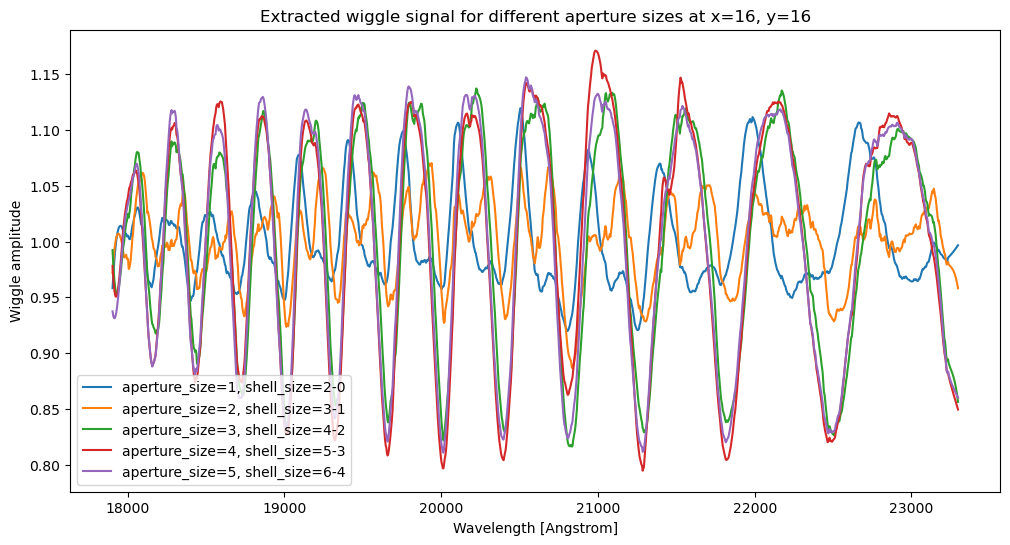

In [8]:
plt.rcParams["figure.figsize"] = (12, 6)

for s in np.arange(1, 6, 1):
    wiggle_signal, wiggle_noise = wcleaner.get_wiggle_data(
        quasar_x,
        quasar_y,
        aperture_radius=s,
        annulus_outer_radius=s + 1,
        annulus_inner_radius=s - 1,
    )
    plt.plot(
        wavelengths,
        Util.lighter_smooth_curve(wiggle_signal),
        label=f"aperture_size={s}, shell_size={s + 1}-{s - 1}",
    )

plt.legend()
plt.title(
    f"Extracted wiggle signal for different aperture sizes at x={quasar_x}, y={quasar_y}"
)
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel("Wiggle amplitude")
plt.show()

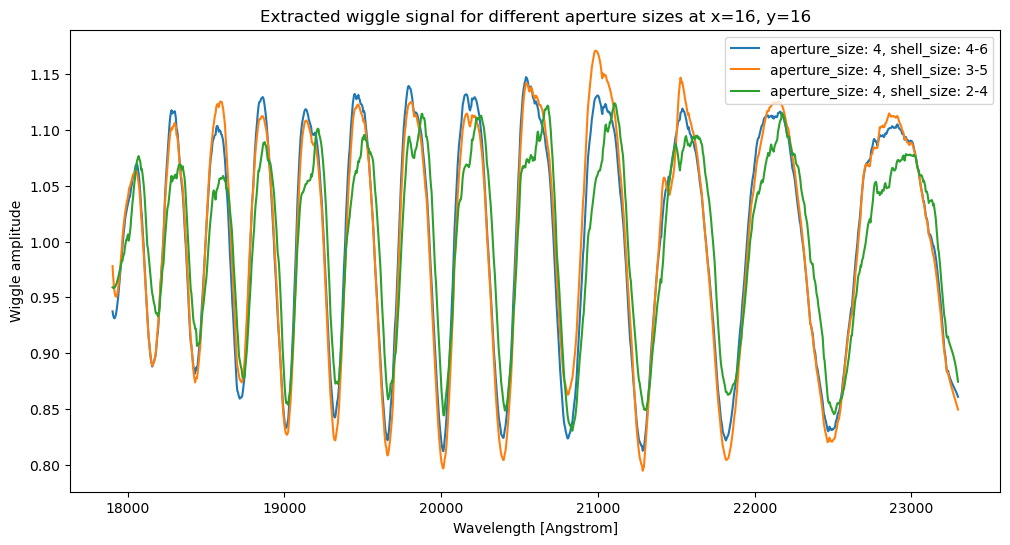

In [9]:
for i in range(0, 3, 1):
    wiggle_signal, wiggle_noise = wcleaner.get_wiggle_data(
        quasar_x,
        quasar_y,
        aperture_radius=4,
        annulus_outer_radius=4 - i + 2,
        annulus_inner_radius=4 - i,
    )
    plt.plot(
        wavelengths,
        Util.lighter_smooth_curve(wiggle_signal),
        # yerr=wiggle_noise,
        # marker="o",
        # markersize=2,
        # linestyle="None",
        label=f"aperture_size: {4}, shell_size: {4 - i}-{4 - i + 2}",
    )
plt.legend()
plt.title(
    f"Extracted wiggle signal for different aperture sizes at x={quasar_x}, y={quasar_y}"
)
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel("Wiggle amplitude")
plt.show()

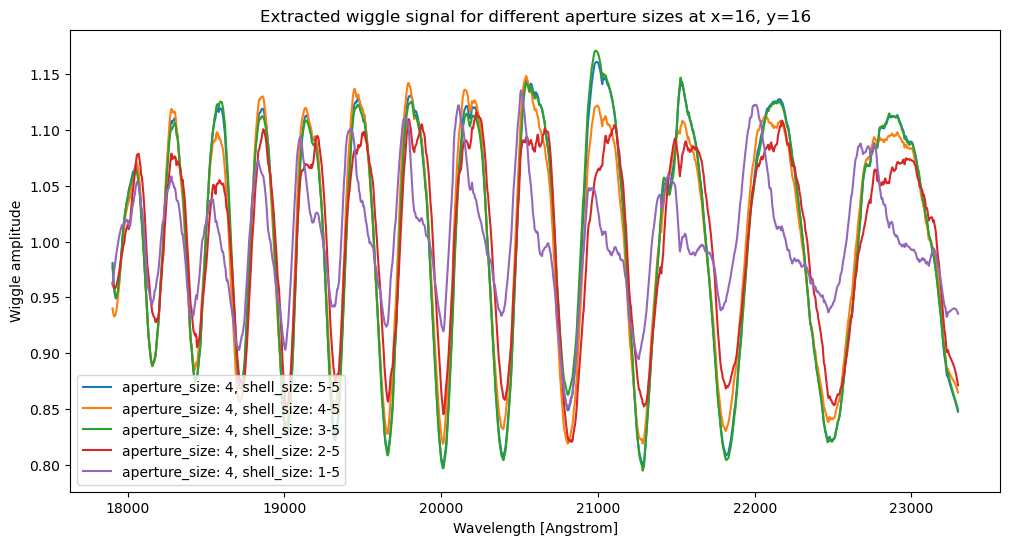

In [10]:
for i in range(0, 5, 1):
    wiggle_signal, wiggle_noise = wcleaner.get_wiggle_data(
        quasar_x,
        quasar_y,
        aperture_radius=4,
        annulus_outer_radius=5,
        annulus_inner_radius=5 - i,
    )
    plt.plot(
        wavelengths,
        Util.lighter_smooth_curve(wiggle_signal),
        # yerr=wiggle_noise,
        # marker="o",
        # markersize=2,
        # linestyle="None",
        label=f"aperture_size: {4}, shell_size: {5 - i}-{5}",
    )
plt.legend()
plt.title(
    f"Extracted wiggle signal for different aperture sizes at x={quasar_x}, y={quasar_y}"
)
plt.xlabel("Wavelength [Angstrom]")
plt.ylabel("Wiggle amplitude")
plt.show()

From the above tests, choosing `aperture_size = 4` and the annulus between 3 and 5 for the remainder of this demo, but you may want to experiment and tune for the best suitability for your data and use case.

In [11]:
aperture_radius = 4
annulus_outer_radius = 5
annulus_inner_radius = 3

## First look into how fitting of the wiggles looks like

Cost:  5592.353928898238
Cost (full model):  1420145.8557470695


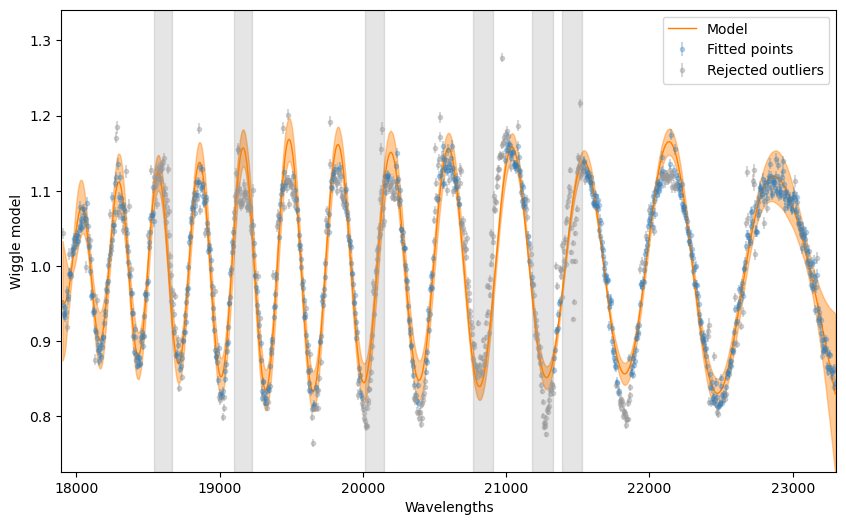

In [12]:
result_params = wcleaner.fit_wiggle_data(
    x=quasar_x,
    y=quasar_y,
    aperture_radius=aperture_radius,
    annulus_outer_radius=annulus_outer_radius,
    annulus_inner_radius=annulus_inner_radius,
    plot=True,
    n_amplitude=8,
    n_frequency=5,
    init_peak_detection_proximity_threshold=30,  # minimum distance between peaks/troughs to help avoid initial misidentification
    verbose=True,
    use_huber_loss=False,
    outlier_rejection_method="fdr",  # can alternatively use "sigma_clipping"
    fdr_alpha=0.05,  # FDR threshold for outlier rejection
    fdr_outlier_max_fraction=0.2,  # Maximum fraction of outliers allowed by FDR
    extract_covariance=True,
    fit_full_model=True,
    include_scatter=False,  # if True, intrinsic scatter around the fit will be accounted for, which will inflate the uncertainty levels of the fitted parameters
)

We have to set the `asymmetric_sharpenning=True` in the `WiggleCleaner` initialization. The `symmetric_sharpening` is also set to `True` for sharper peaks than a sine function. These two options can be chosen individually, and you may experiment for the best settings suited for your use case.

The model for the modulation curve is:
$$
w(x) = 1 + A(x) \left[ \sin(\phi(x)) + k_1  \sin(\phi(x))^2 + k_2  \sin(3\phi(x))\right] + c(x)
$$

Here, $\sin(\phi(x))^2$ term creates the asymmetric sharpness, and the $\sin(3\phi(x))$ term creates the symmetric sharpness. The phase $\phi(x)$, amplitude $A(x)$ and continuum offset $c(x)$ are described with polynomials with orders `n_frequency`, `n_amplitude`, respectively.

## Using BIC to select the best combination of polynomial orders

Computing BIC for choices of n_amplitude and n_frequency...


  0%|          | 0/14 [00:00<?, ?it/s]

n_amplitude: 5, n_frequency: 2, bic: 36665.22245672157
n_amplitude: 6, n_frequency: 2, bic: 26259.57536589158
n_amplitude: 7, n_frequency: 2, bic: 26195.020660770802
n_amplitude: 10, n_frequency: 2, bic: 19841.47454365872
n_amplitude: 9, n_frequency: 5, bic: 19812.945441881
n_amplitude: 10, n_frequency: 7, bic: 19439.312857278153
Best n_amplitude:  10
Best n_frequency:  7


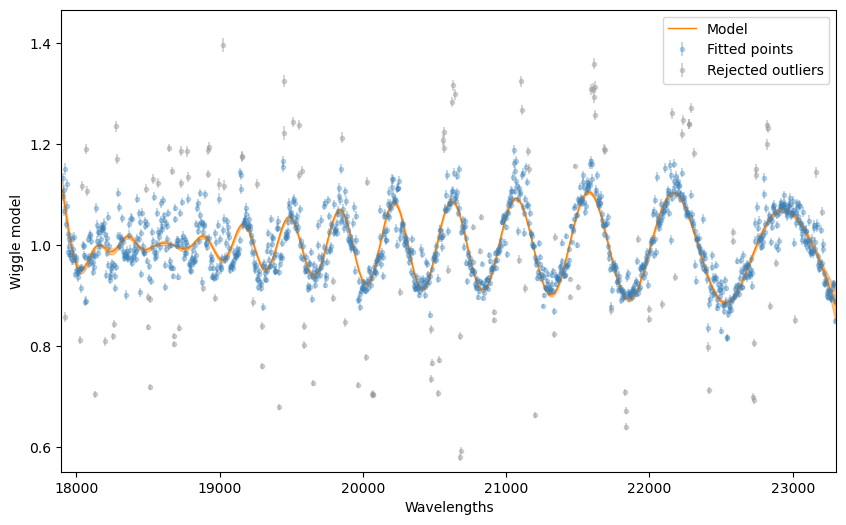

(array([ 7.75043176e-02, -5.43110926e-02,  2.68843043e-02, -4.66678503e-02,
        -5.69119649e-02, -8.92378211e-02, -8.51332076e-02, -9.59920108e-02,
        -1.14321197e-01, -9.15232109e-02, -1.33030895e-01, -9.48534723e-02,
         5.29704551e+01,  5.43615335e+01,  4.82706673e+01,  4.37046862e+01,
         4.13960792e+01,  3.69822760e+01,  3.33179521e+01,  3.09303111e+01,
         2.89994458e+01,  5.46769294e+01]),
 array([[ 1.24048944e-04, -7.74936129e-05,  3.99339846e-05,
         -1.75897836e-05,  8.76053748e-06, -4.40615314e-06,
          1.95366178e-06, -1.17866780e-06,  7.91422701e-07,
         -3.84368167e-07, -1.55599775e-07, -1.77246998e-07,
          5.28390821e-04,  3.75679320e-03, -1.67556988e-03,
          9.16080628e-04, -6.43385567e-04,  6.70911801e-05,
         -8.01234347e-05,  3.47298876e-06, -2.23040348e-05,
          1.41120787e-05],
        [-7.74936129e-05,  1.77705223e-04, -1.11255217e-04,
          5.27087017e-05, -2.69854357e-05,  1.33751298e-05,
         

In [34]:
wcleaner.fit_wiggle_data_with_model_selection(
    15,  # quasar_x,
    15,  # quasar_y,
    aperture_radius=aperture_radius,
    annulus_outer_radius=aperture_radius + 1,
    annulus_inner_radius=aperture_radius - 1,
    plot=True,
    n_amplitude=15,
    n_frequency=15,
    min_n_amplitude=5,
    min_n_frequency=2,
    selection_criteria="bic",
    init_peak_detection_proximity_threshold=200,
    include_scatter=False,
    outlier_rejection_method="fdr",
    use_huber_loss=False,
    fdr_alpha=0.01,
    fdr_outlier_max_fraction=0.10,
    extract_covariance=True,
    fit_full_model=True,
)

## Finally, let `raccoon` clean your whole datacube. 🦝

You can setup a mask to restrict the region with spaxels to be cleaned.

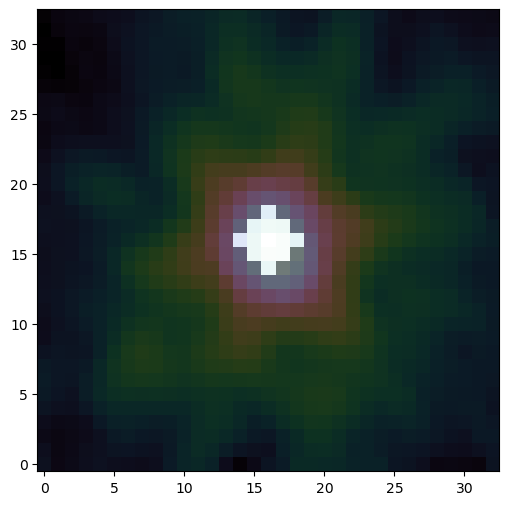

In [24]:
%matplotlib inline

mask = np.zeros_like(data_cube[0], dtype=bool)

center_x = quasar_x
center_y = quasar_y

radius = 2  # pixels

for i in range(center_x - 2 * radius, center_x + 2 * radius):
    for j in range(center_y - 2 * radius, center_y + 2 * radius):
        if (i - center_x) ** 2 + (j - center_y) ** 2 <= radius**2:
            mask[i, j] = True

plt.imshow(np.log10(np.nansum(data_cube, axis=0)), cmap="cubehelix", origin="lower")
plt.imshow(mask, alpha=0.5, cmap="cubehelix", origin="lower", vmin=0, vmax=1)
plt.show()

If `min_n_amplitude` and `min_n_frequency` are provided below, then the best combination according model selection (using BIC or $\chi^2$) will be used. But, it will be taking longer since the fitting is going through all the combinations within the given range.

Cleaning spaxels:   0%|          | 0/13 [00:00<?, ?it/s]

###########################
Fitting spaxel: 14, 16


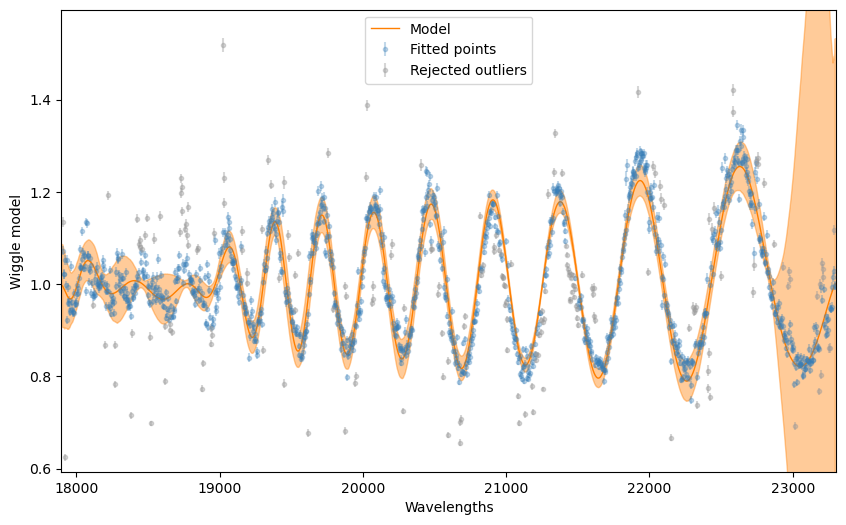

Wiggle detection sigma: 12.99
Model variance: 0.1187, residual variance: 0.0346, ratio: 3.4288
Wiggle detected. Cleaning spaxel: 14, 16.
###########################
Fitting spaxel: 15, 15


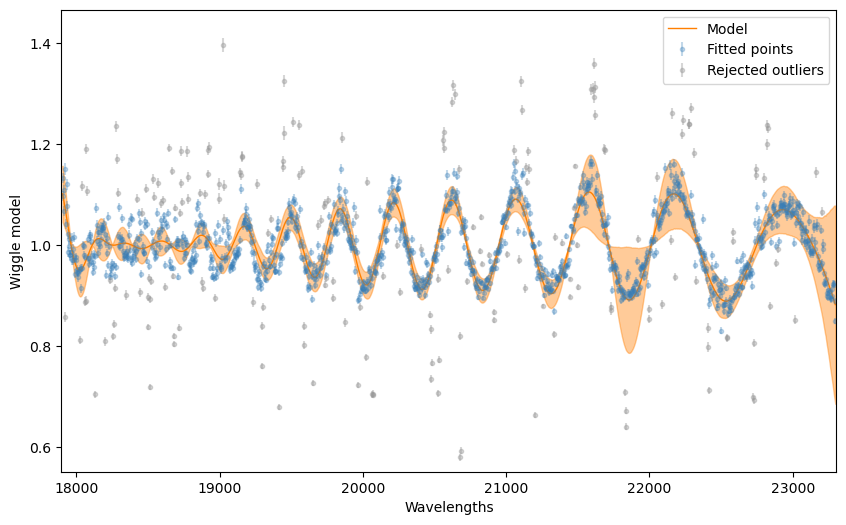

Wiggle detection sigma: 7.75
Model variance: 0.0568, residual variance: 0.0267, ratio: 2.1245
Wiggle detected. Cleaning spaxel: 15, 15.
###########################
Fitting spaxel: 15, 16


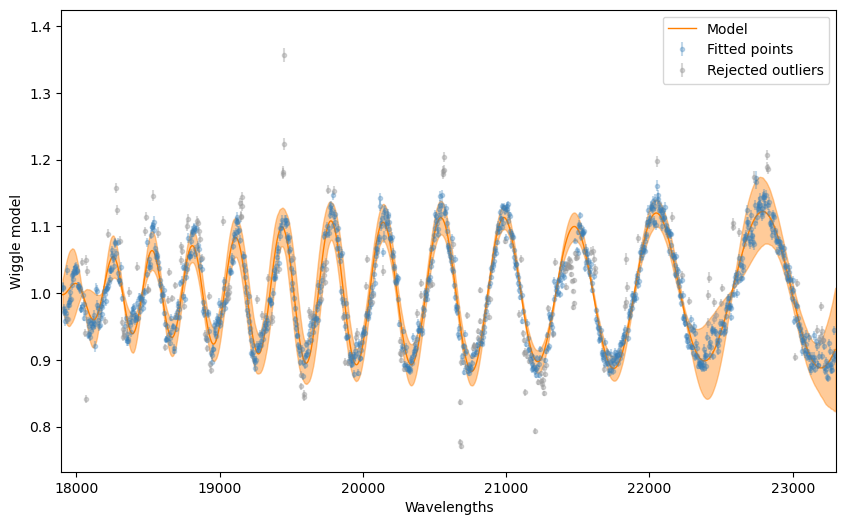

Wiggle detection sigma: 11.53
Model variance: 0.0717, residual variance: 0.0180, ratio: 3.9900
Wiggle detected. Cleaning spaxel: 15, 16.
###########################
Fitting spaxel: 15, 17


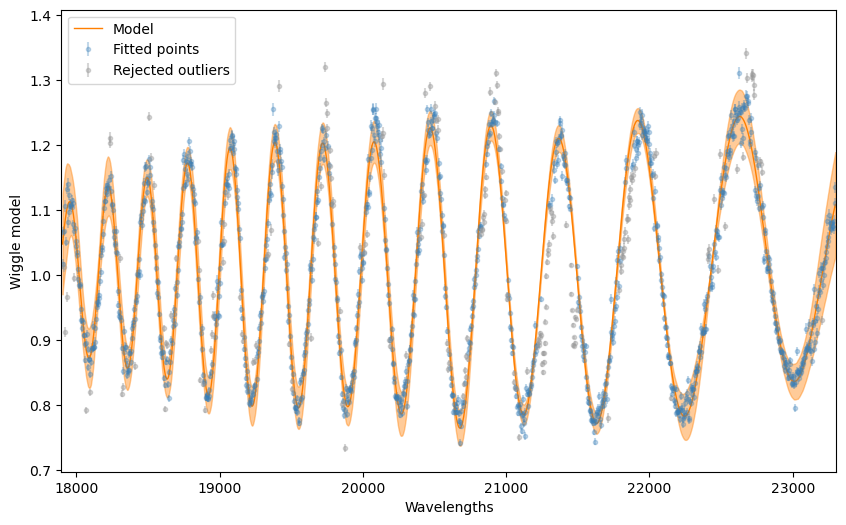

Wiggle detection sigma: 22.62
Model variance: 0.1443, residual variance: 0.0227, ratio: 6.3425
Wiggle detected. Cleaning spaxel: 15, 17.
###########################
Fitting spaxel: 16, 14


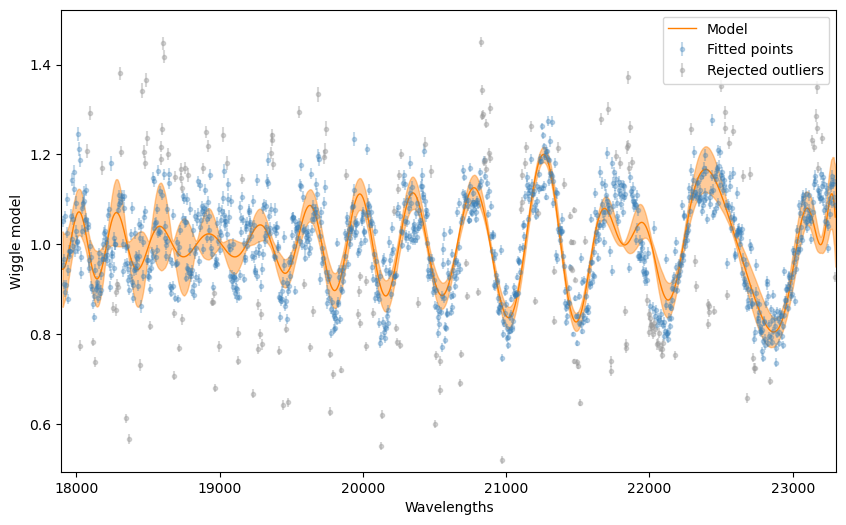

Wiggle detection sigma: 8.39
Model variance: 0.0855, residual variance: 0.0623, ratio: 1.3721
Wiggle detected. Cleaning spaxel: 16, 14.
###########################
Fitting spaxel: 16, 15


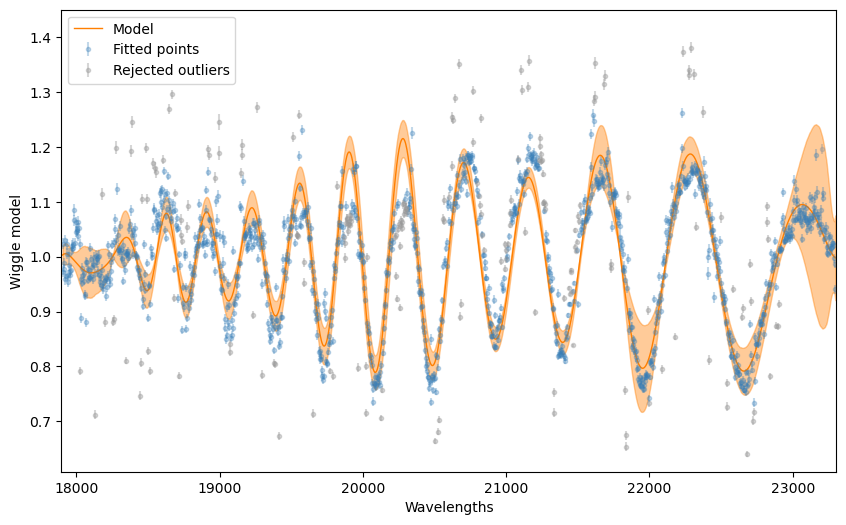

Wiggle detection sigma: 13.96
Model variance: 0.1059, residual variance: 0.0393, ratio: 2.6986
Wiggle detected. Cleaning spaxel: 16, 15.
###########################
Fitting spaxel: 16, 16


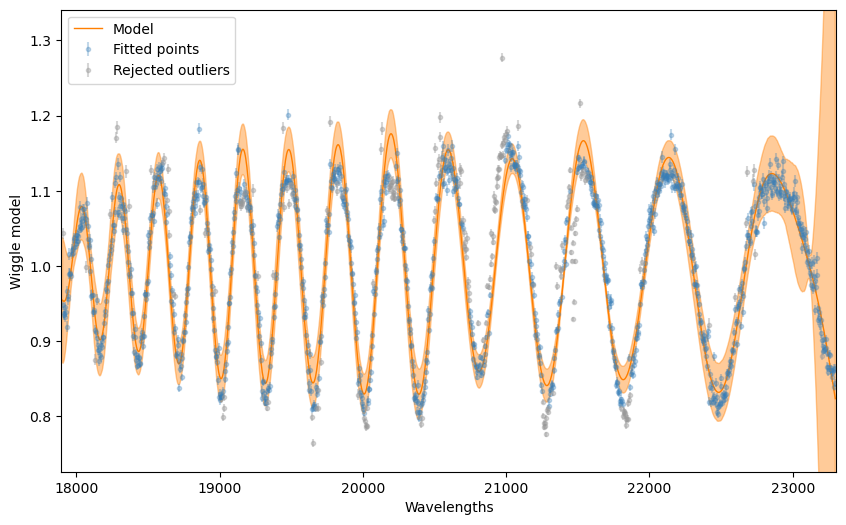

Wiggle detection sigma: 18.41
Model variance: 0.1017, residual variance: 0.0205, ratio: 4.9671
Wiggle detected. Cleaning spaxel: 16, 16.
###########################
Fitting spaxel: 16, 17


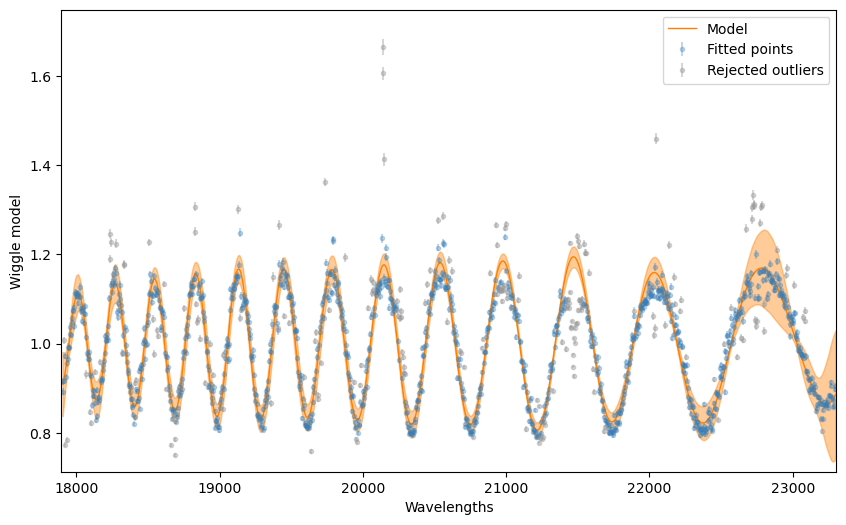

Wiggle detection sigma: 18.92
Model variance: 0.1156, residual variance: 0.0246, ratio: 4.6974
Wiggle detected. Cleaning spaxel: 16, 17.
###########################
Fitting spaxel: 16, 18


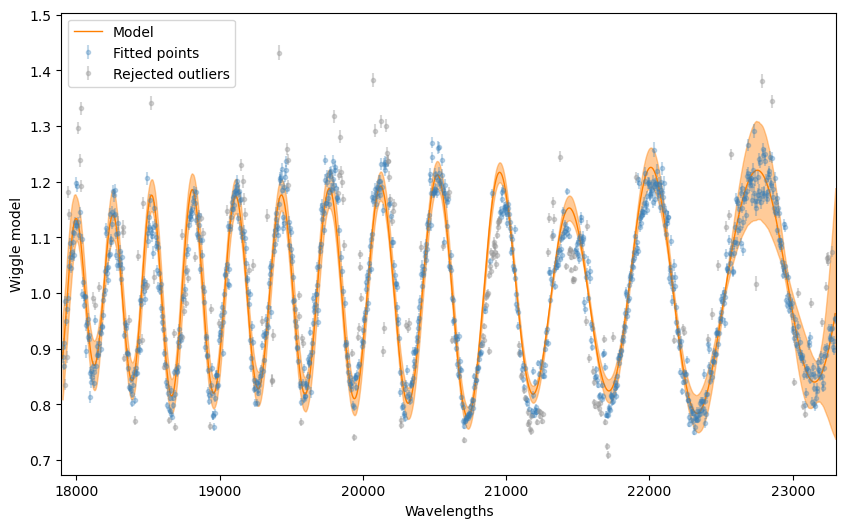

Wiggle detection sigma: 16.35
Model variance: 0.1353, residual variance: 0.0338, ratio: 4.0078
Wiggle detected. Cleaning spaxel: 16, 18.
###########################
Fitting spaxel: 17, 15


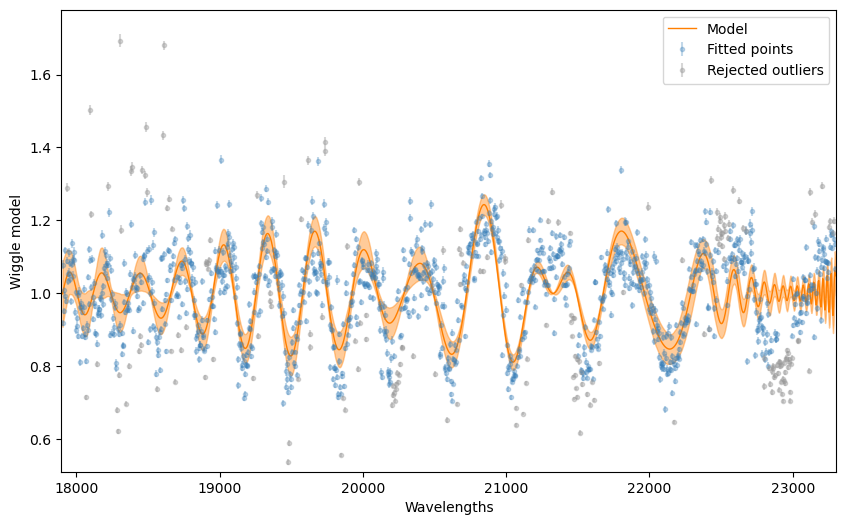

Wiggle detection sigma: 10.61
Model variance: 0.0913, residual variance: 0.0812, ratio: 1.1249
Wiggle detected. Cleaning spaxel: 17, 15.
###########################
Fitting spaxel: 17, 16


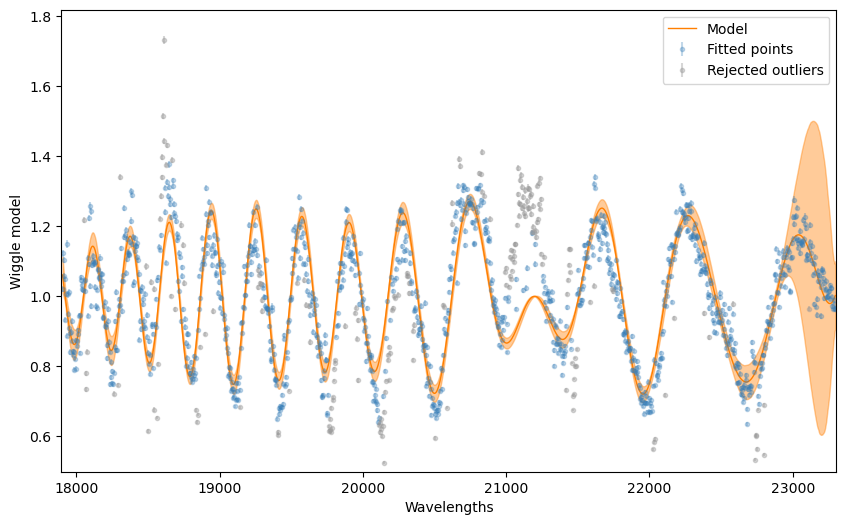

Wiggle detection sigma: 22.79
Model variance: 0.1575, residual variance: 0.0658, ratio: 2.3939
Wiggle detected. Cleaning spaxel: 17, 16.
###########################
Fitting spaxel: 17, 17


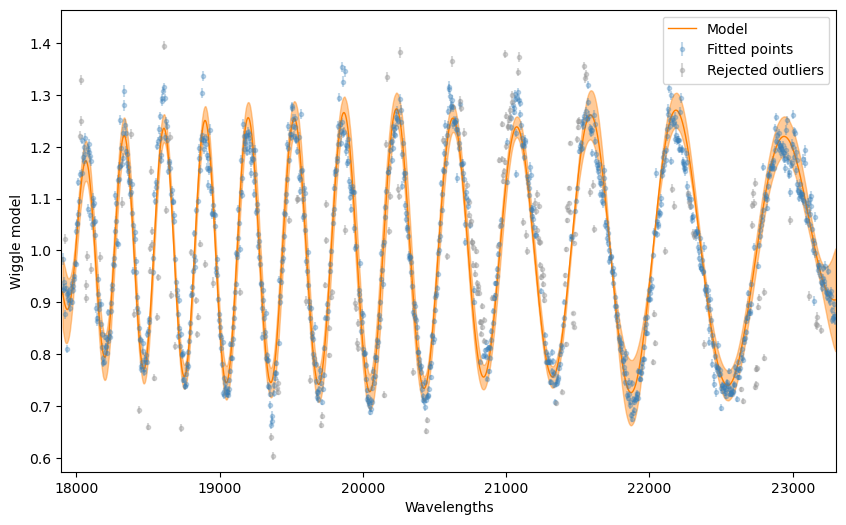

Wiggle detection sigma: 23.47
Model variance: 0.1777, residual variance: 0.0359, ratio: 4.9509
Wiggle detected. Cleaning spaxel: 17, 17.
###########################
Fitting spaxel: 18, 16


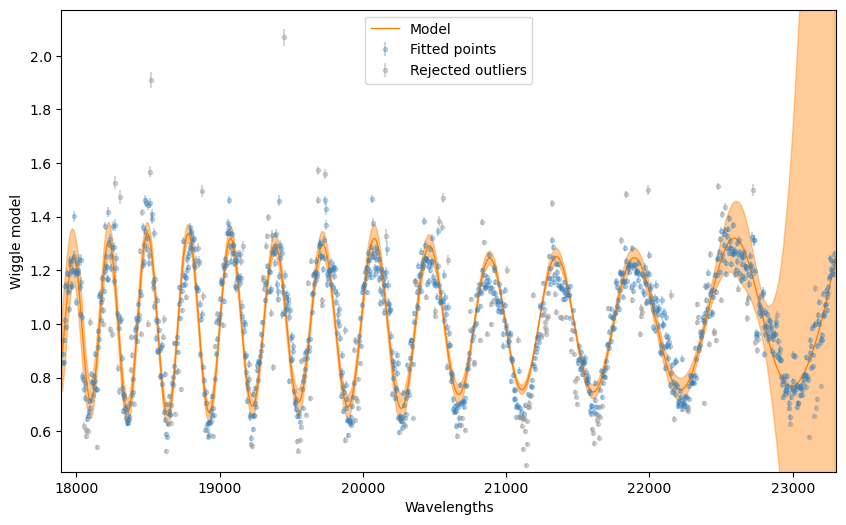

Wiggle detection sigma: 18.72
Model variance: 0.2023, residual variance: 0.0714, ratio: 2.8315
Wiggle detected. Cleaning spaxel: 18, 16.
Cleaning done!


In [35]:
cleaned_cube, cleaned_noise_cube, cleaned_map = wcleaner.clean_cube(
    wiggle_detection_sigma_threshold=5.0,
    wiggle_detection_variance_ratio_threshold=0.2,
    n_amplitude=10,
    n_frequency=7,
    fit_full_model=True,
    min_n_amplitude=None,
    min_n_frequency=None,
    cleaning_mask=mask,
    init_peak_detection_proximity_threshold=200,
    aperture_radius=aperture_radius,
    annulus_outer_radius=annulus_outer_radius,
    annulus_inner_radius=annulus_inner_radius,
    plot=True,
    verbose=True,
    extract_uncertainty=True,
    include_scatter=False,
    outlier_rejection_method="fdr",
    use_huber_loss=False,
    fdr_alpha=0.01,
    fdr_outlier_max_fraction=0.15,
    sigma_clip_sigma=3,
    sigma_clip_max_iterations=20,
    num_samples_uncertainty_region=1000,
)

plt.show()

### Let's see which spaxels were cleaned in the end, by having a wiggle signal detected above the chosen threshold.

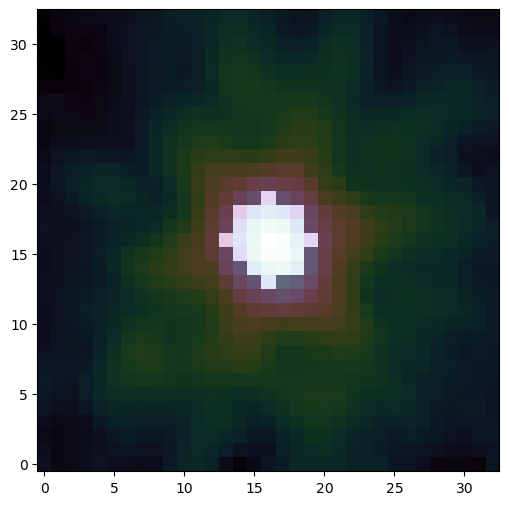

In [21]:
%matplotlib inline

plt.imshow(
    np.log10(np.nansum(data_cube, axis=0)), cmap="cubehelix", origin="lower",
)
plt.imshow(cleaned_map, alpha=0.5, cmap="cubehelix", origin="lower", vmin=0, vmax=1)
plt.show()

## Save the cleaned cube if everything looks fine!

In [17]:
# output_file_path = ...
# with fits.open(datacube_file) as hdu:
#     hdu["SCI"].data = cleaned_cube
#     hdu["ERR"].data = cleaned_noise_cube

#     hdu.writeto(
#         output_file_path,
#     )